# Simple Linear Regression

Libraries

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_regression

Generating Data

In [15]:
X, y = make_regression(
    n_samples=100,
    n_features=1,
    noise=10,
    random_state=42
)
data = pd.DataFrame({'X': X.flatten(), 'y': y})


EDA

In [16]:
data.shape

(100, 2)

In [17]:
print("X")
data['X'].head()
print()
data['X'].info()
print()
data['X'].describe()

print("\ny")
print(data['y'].head())
print()
data['y'].info()
print()
data['y'].describe()

X

<class 'pandas.core.series.Series'>
RangeIndex: 100 entries, 0 to 99
Series name: X
Non-Null Count  Dtype  
--------------  -----  
100 non-null    float64
dtypes: float64(1)
memory usage: 932.0 bytes


y
0    50.779929
1   -10.065270
2   -34.918392
3    10.526743
4   -17.738377
Name: y, dtype: float64

<class 'pandas.core.series.Series'>
RangeIndex: 100 entries, 0 to 99
Series name: y
Non-Null Count  Dtype  
--------------  -----  
100 non-null    float64
dtypes: float64(1)
memory usage: 932.0 bytes



count    100.000000
mean      -3.449530
std       41.321720
min     -118.027454
25%      -30.170786
50%       -0.634702
75%       23.478589
max       89.033145
Name: y, dtype: float64

In [18]:
data['X'].isnull().sum(), data['y'].isnull().sum()

(np.int64(0), np.int64(0))

Visualization

<Axes: xlabel='X', ylabel='y'>

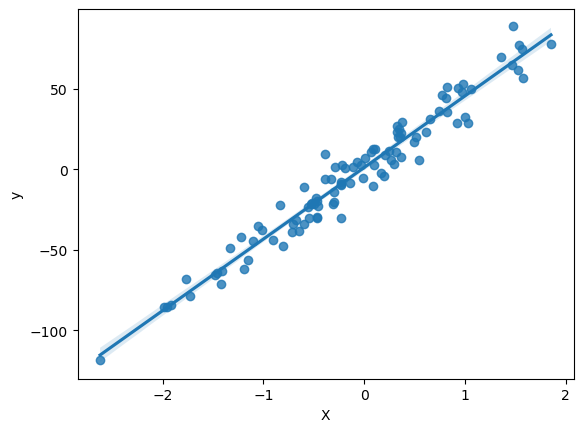

In [19]:
sns.regplot(x=data['X'], y=data['y'])

Model

In [20]:
class LinearRegression:
    def __init__(self, X, y, intercept: bool = True):
        self.X = np.array(X)
        self.y = np.array(y)
        self.intercept_flag = intercept
        self.slope = None
        self.intercept = None

    def fit(self):
        x_mean = np.mean(self.X)
        y_mean = np.mean(self.y)
        
        # Compute Slope (b1)
        numerator = np.sum((self.X - x_mean) * (self.y - y_mean))
        denominator = np.sum((self.X - x_mean) ** 2)
        self.slope = numerator / denominator
        
        # Compute Intercept (b0)
        if self.intercept_flag:
            self.intercept = y_mean - self.slope * x_mean
        else:
            self.intercept = 0
        
    def predict(self, X_new):
        X_new = np.array(X_new)
        return self.intercept + self.slope * X_new